In [17]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from tqdm import tqdm

from sklearn.feature_selection import SelectKBest, mutual_info_regression, RFE, SelectFromModel

In [2]:
ds = fetch_california_housing()
X, y = ds.data, ds.target

indexes = np.arange(len(y))
np.random.seed(52342)
np.random.shuffle(indexes)

X = X[indexes, :]
y = y[indexes]

## Отбор по корреляции

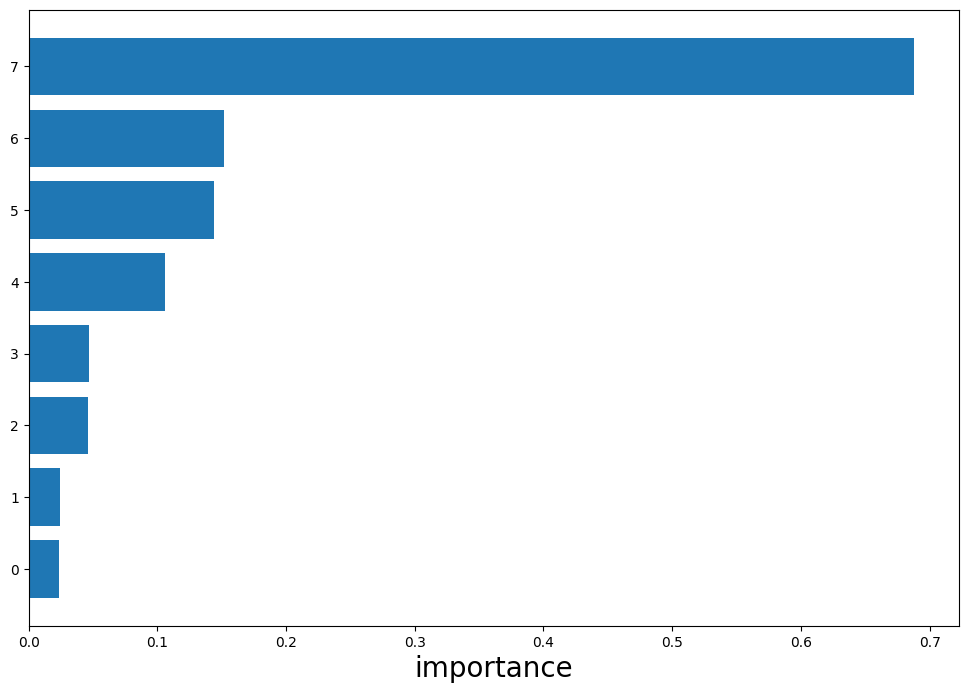

In [3]:
features_ind = np.arange(X.shape[1])
corrs = np.abs([pearsonr(X[:, i], y)[0] for i in features_ind])
importances_sort = np.argsort(corrs)

fig = plt.figure(figsize = (12, 8))
plt.barh(features_ind, corrs[importances_sort])
plt.xlabel('importance', fontsize = 20)
X = X[:, importances_sort]

In [10]:
feature_counts = np.arange(X.shape[1])

def scores_by_cnt(reg):
    scores = []
    for features_part in tqdm(feature_counts):
        X_part = X[:,importances_sort[features_part:]]
        scores.append(cross_val_score(reg, X_part, y).mean())
    return scores

linreg_scores = scores_by_cnt(LinearRegression())
rf_scores = scores_by_cnt(RandomForestRegressor(n_estimators = 100, max_depth = 3, n_jobs = -1))

100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:07<00:00,  1.00it/s]


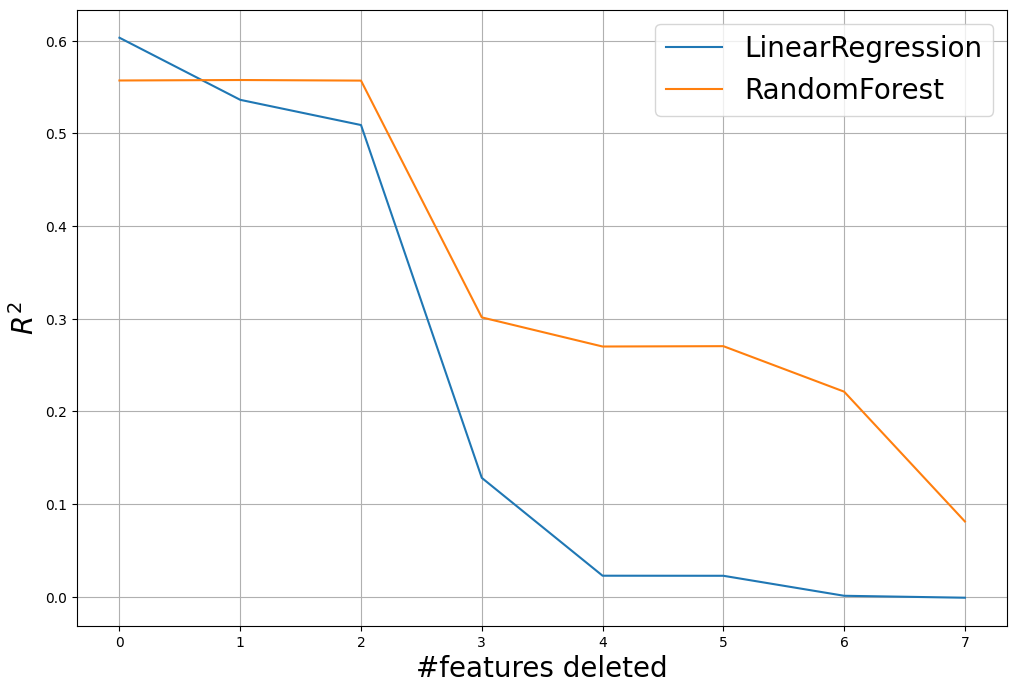

In [6]:
fig = plt.figure(figsize=(12,8))

plt.plot(feature_counts, linreg_scores, label = 'LinearRegression')
plt.plot(feature_counts, rf_scores, label = 'RandomForest')
plt.legend(loc='best', fontsize=20)
plt.xlabel('#features deleted', fontsize=20)
plt.ylabel('$R^2$', fontsize=20)
plt.grid()

## Отбор по взаимной информации 

In [11]:
select = SelectKBest(score_func=mutual_info_regression, k='all')
z = select.fit_transform(X, y)

importances_sort = np.argsort(select.scores_)

linreg_scores = scores_by_cnt(LinearRegression())
rf_scores = scores_by_cnt(RandomForestRegressor(n_estimators = 100, max_depth = 3, n_jobs = -1))

100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:07<00:00,  1.02it/s]


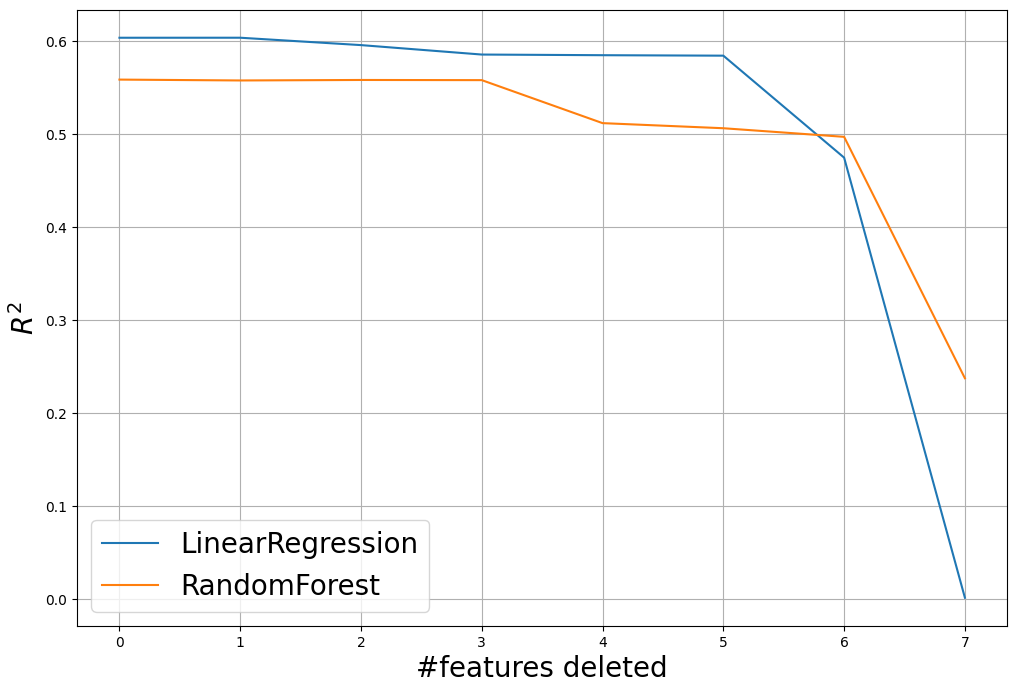

In [12]:
fig = plt.figure(figsize=(12,8))

plt.plot(feature_counts, linreg_scores, label = 'LinearRegression')
plt.plot(feature_counts, rf_scores, label = 'RandomForest')
plt.legend(loc='best', fontsize=20)
plt.xlabel('#features deleted', fontsize=20)
plt.ylabel('$R^2$', fontsize=20)
plt.grid()

## Рекурсивный отбор

In [14]:
def scores_by_rfe(reg):
    scores = []
    for num_features in tqdm(np.arange(8,0,-1)):
        estimator = LinearRegression()
        selector = RFE(estimator, n_features_to_select=num_features, step=1)
        selector = selector.fit(X, y)
        
        X_part = selector.transform(X)
        scores.append(cross_val_score(reg, X_part, y).mean())
    return scores

linreg_scores = scores_by_rfe(LinearRegression())
rf_scores = scores_by_rfe(RandomForestRegressor(n_estimators = 100, max_depth = 3, n_jobs = -1))

100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:08<00:00,  1.05s/it]


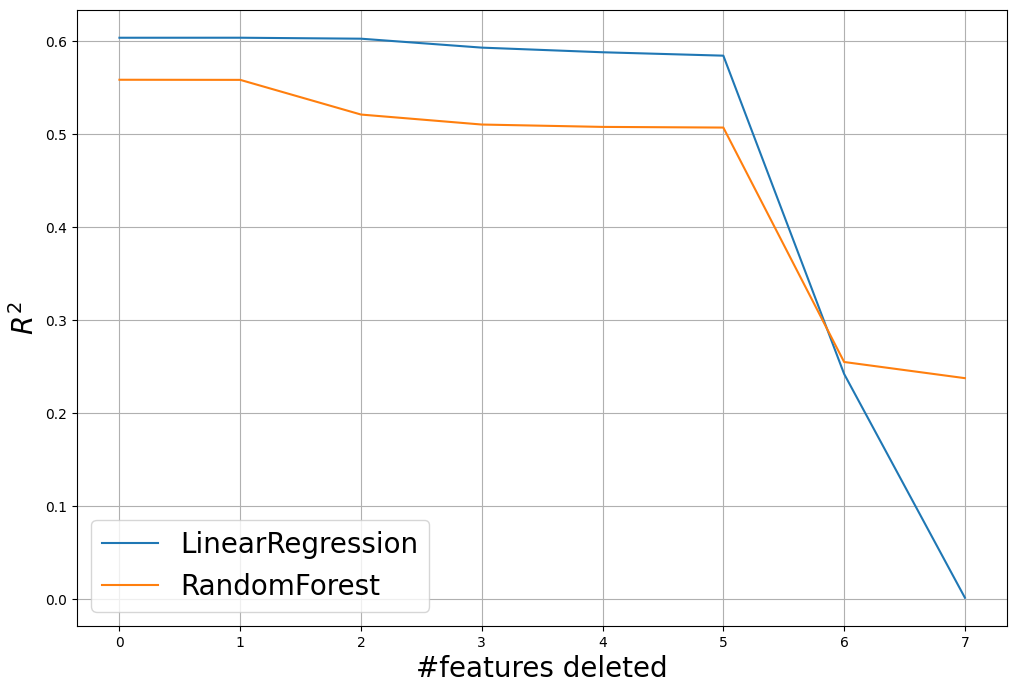

In [15]:
fig = plt.figure(figsize=(12,8))

plt.plot(feature_counts, linreg_scores, label = 'LinearRegression')
plt.plot(feature_counts, rf_scores, label = 'RandomForest')
plt.legend(loc='best', fontsize=20)
plt.xlabel('#features deleted', fontsize=20)
plt.ylabel('$R^2$', fontsize=20)
plt.grid()

## Отбор по модели

In [21]:
estimator = LinearRegression()
selector = SelectFromModel(estimator)
slector = selector.fit(X, y)

importances_sort = np.argsort(selector.estimator_.coef_)

linreg_scores = scores_by_cnt(LinearRegression())
rf_scores = scores_by_cnt(RandomForestRegressor(n_estimators = 100, max_depth = 3, n_jobs = -1))

100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:08<00:00,  1.03s/it]


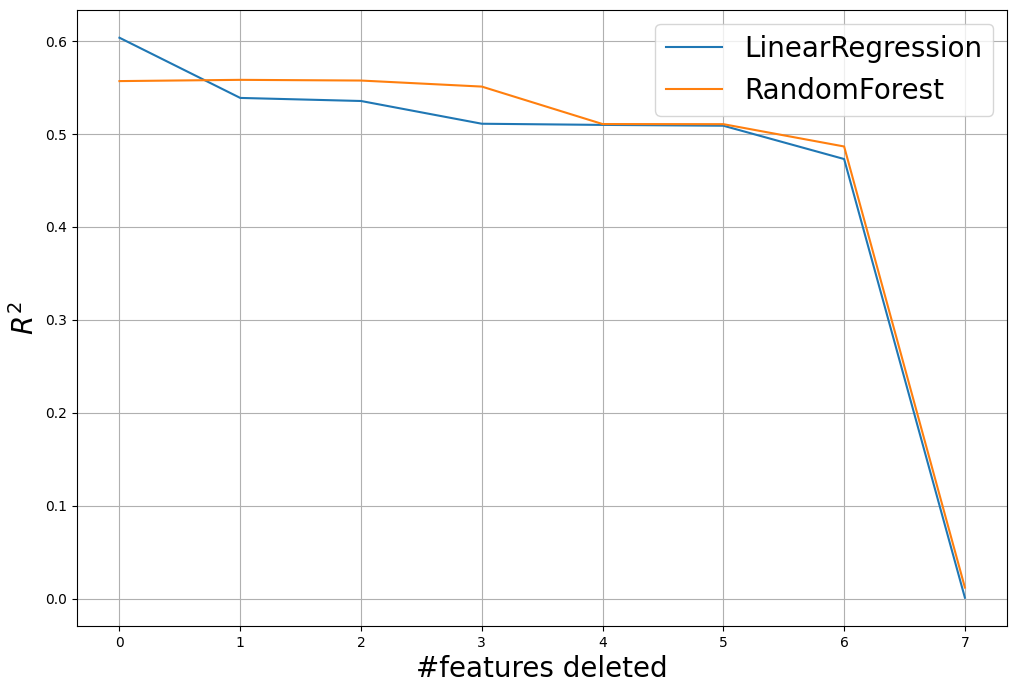

In [19]:
fig = plt.figure(figsize=(12,8))

plt.plot(feature_counts, linreg_scores, label = 'LinearRegression')
plt.plot(feature_counts, rf_scores, label = 'RandomForest')
plt.legend(loc='best', fontsize=20)
plt.xlabel('#features deleted', fontsize=20)
plt.ylabel('$R^2$', fontsize=20)
plt.grid()